## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [ ]:
!pip install evaluate

In [ ]:
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, TrainingArguments, AutoModelForSequenceClassification
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

pd.set_option("display.max_colwidth", None)

In [ ]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
# swahili_news.head()

In [ ]:
swahili_news["category"].value_counts()

,count
category,
kitaifa,10242
michezo,6004
burudani,2229
uchumi,2028
kimataifa,1906
afya,859


<Axes: xlabel='category', ylabel='count'>

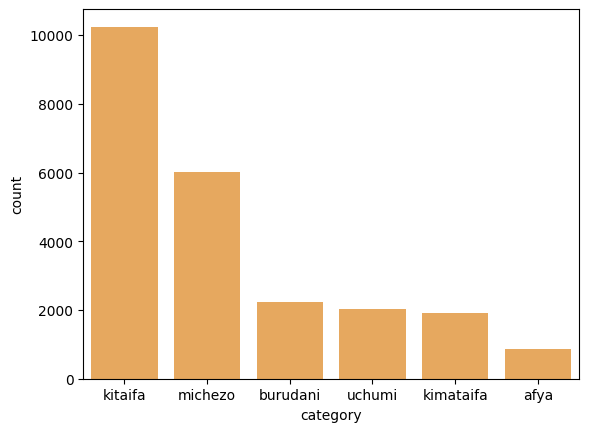

In [ ]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

In [ ]:
# swahili_news.loc[23258, "content"].lower().rstrip().lstrip()

In [ ]:
# swahili_news[swahili_news["category"] == "kitaifa"].head()

In [ ]:
[news for news in swahili_news["content"].tolist() if "serikali imesema haitakuwa" in news]

[]

In [ ]:
merged_swahili_news = pd.concat([swahili_news, holdout_train])

<Axes: xlabel='category', ylabel='count'>

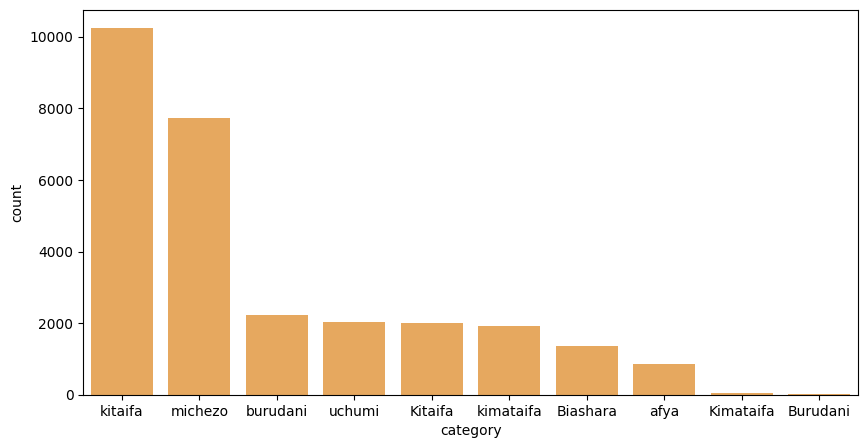

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="category",
    data=merged_swahili_news,
    color="#fdaa48",
    order=merged_swahili_news["category"].value_counts().index
    )

In [ ]:
merged_swahili_news["category"].unique()

array(['uchumi', 'kitaifa', 'michezo', 'kimataifa', 'burudani', 'afya',
       'Kitaifa', 'Biashara', 'Kimataifa', 'Burudani'], dtype=object)

In [ ]:
# merged_swahili_news[merged_swahili_news["content"].duplicated()].loc[0, "content"]

merged_swahili_news[merged_swahili_news["content"].duplicated()]

id  \
40    SW29020   
50    SW13033   
142   SW29598   
211   SW24604   
262   SW23250   
...       ...   
5146    SW993   
5147    SW994   
5148    SW996   
5149    SW997   
5150    SW999   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [ ]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [ ]:
# tokenizer.tokenize(merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]["content"])

In [ ]:
def text_preprocessing(text):
    text = text.lower().rstrip().lstrip()
    return re.sub(r'[.,\'\[\]]', '', text)

merged_swahili_news[["content", "category"]] = merged_swahili_news[["content", "category"]].map(text_preprocessing)
merged_swahili_news.head(1)

,id,content,category
0,SW4670,bodi ya utalii tanzania (ttb) imesema itafanya misafara ya kutangaza utalii kwenye miji minne nchini china kati ya juni 19 hadi juni 26 mwaka huumisafara hiyo itatembelea miji ya beijing juni 19 shanghai juni 21 nanjig juni 24 na changsha juni 26mwenyekiti wa bodi ttb jaji mstaafu thomas mihayo ameyasema hayo kwenye mkutano na waandishi wa habari jijini dar es salaam“tunafanya jitihada kuhakikisha tunavuna watalii wengi zaidi kutoka china hasa tukizingatia umuhimu wa soko la sekta ya utalii nchini” amesema jaji mihayonovemba 2018 ttb ilifanya ziara kwenye miji ya beijing shanghai chengdu guangzhou na hong kong kutangaza vivutio vya utalii sanjari kuzitangaza safari za ndege za air tanzaniaziara hiyo inaelezwa kuzaa matunda ikiwa ni pamoja na watalii zaidi ya 300 kuja nchini mei mwaka huu kutembelea vivutio vya utalii,uchumi


In [ ]:
merged_swahili_news.tail(1)

,id,content,category
5150,SW999,akizungumza mara baada ya kutiwa saini kwa makubaliano hayo jana jioni waziri wa nchi ofisi ya waziri mkuu tawala za mikoa na serikali za mitaa hawa ghasia alisema uwekezaji huo unatarajiwa kuleta manufaa kwa shirika hilo kwani uwekezaji wake pia utasaidia kutoa elimu kwa vitendo juu ya ufugaji kwa kada mbalimbalialisema miaka ya nyuma shirika hilo lilikuwa likisifika kwa ufugaji wa kuku kabla ya kusitisha shughuli hizo kutokana na uwepo wa sababu mbalimbali na kusababisha shirika hilo kukosa mapato yaliyokuwa yakitokana na uuzaji wa kuku na mayaimkurugenzi wa shirika la elimu kibaha cyprian mpemba alisema uwekezaji huo wa miaka 66 mbali na kuingizia shirika hilo kiasi cha sh milioni 100 kila mwaka pia utawawezesha kuvuna kiasi kingine kama hicho kama ada ya uingiaji katika eneo hiloalisema itachukua muda wa miaka nane hadi uwekezaji rasmi ukamilike katika eneo hilo ukihusisha idara mbalimbali ikiwemo ujenzi wa viwanda vya usindikaji wa nyama na utengenezaji wa soseji huku kila baada ya miaka miwili wakikamilisha ujenzi wa eneo yakiwemo maeneo ya kufugia kuku haompemba alisema matarajio baada ya mika miwili ijayo mradi huo utaweza kuzalisha kuku milioni 27 huku wakitoa ajira kwa watu 120 na ukikamilika utazalisha kuku milioni 165 pamoja na kutoa ajira kwa watu 700 hatua aliyosema itasaidia kuleta mapinduzi katika ufugaji wa kuku hapa nchini sambamba na kutoa elimu kwa wanafunzi kutoka vyuo mbalimbalinaye mtendaji mkuu wa kampuni hiyo hesham ewies alisema malengo yao ni kuibadilisha kibaha kwa muda mfupi kwa kulifanya kuwa eneo linalosifika kutokana na shughuli za ufugaji wa kuku huku zaidi wakilenga kuondoa upungufu wa mahitaji ya bidhaa ya kuku yaliyopo kwa sasa nchinialisema watarajio yao baada ya miaka michache ijayo tanzania itaweza kusifika kwa usafirishaji wa bidhaa zitokanazo na kuku kwenda nje ya nchi na hivyo kuliongeza taifa mapato,biashara


In [ ]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0]

4911

In [ ]:
merged_swahili_news[~merged_swahili_news["content"].duplicated()].shape[0]

23508

In [ ]:
merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] + merged_swahili_news[~merged_swahili_news["content"].duplicated()].shape[0]

28419

In [ ]:
merged_swahili_news.shape

(28419, 3)

In [ ]:
print(f"{(merged_swahili_news[merged_swahili_news["content"].duplicated()].shape[0] / merged_swahili_news.shape[0]) * 100:.2f}% of the merged data set is duplicated.")

17.28% of the merged data set is duplicated.


In [ ]:
merged_swahili_news = merged_swahili_news[~merged_swahili_news["content"].duplicated()]

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/bert-tokenizer-swahili")

# model = AutoModelForTokenClassification.from_pretrained("castorini/afriberta_base")
# tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
# masakhane_tokenizer = AutoTokenizer.from_pretrained("Davlan/afro-xlmr-base")
# swah_tokenizer = AutoTokenizer.from_pretrained("Benjamin-png/swahili-mms-tts-finetuned")
# tokenizer.model_max_length = 512


inputs = tokenizer(
    # padding=True,
    stride=50,
    return_overflowing_tokens=True
)

def tokenize(text):
    encoding = tokenizer(
        text,
        max_length=512,
        truncation=True,
        stride=128,
        return_overflowing_tokens=True,
        padding="max_length"
    )
    return encoding["input_ids"]

In [ ]:
# print("Tokenizing using xlm roberta..")

# def tokenize(text):
#     # tokens = tokenizer.tokenize(text)
#     encoding = tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     # stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
#     token_ids = encoding["input_ids"][0]
#     return tokens, token_ids

# merged_swahili_news["tokenized"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[0])
# merged_swahili_news["token_ids"] = merged_swahili_news["content"].apply(lambda x: tokenize(x)[1])

# print("Now tokenizing using masakhane...")

# def masakhane_tokenize(text):
#     encoding = masakhane_tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [masakhane_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
#     token_ids = encoding["input_ids"]
#     return tokens, token_ids

# merged_swahili_news["masakhane_tokenized"] = merged_swahili_news["content"].apply(lambda x: masakhane_tokenize(x)[0])
# merged_swahili_news["masakhane_token_ids"] = merged_swahili_news["content"].apply(lambda x: masakhane_tokenize(x)[1])

# print("Working on tokenizing using SwahBERT...")

# def swah_tokenize(text):
#     encoding = swah_tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [swah_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]]
#     token_ids = encoding["input_ids"]
#     return tokens, token_ids

# merged_swahili_news["swah_tokenized"] = merged_swahili_news["content"].apply(lambda x: swah_tokenize(x)[0])
# merged_swahili_news["swah_token_ids"] = merged_swahili_news["content"].apply(lambda x: swah_tokenize(x)[1])

In [ ]:
# merged_swahili_news.head(1)

In [ ]:
# merged_swahili_news.loc[0, ["token_ids", "masakhane_token_ids"]]

In [ ]:
# merged_swahili_news["content"].loc[0]

In [ ]:
# merged_swahili_news["token_length"] = merged_swahili_news["tokenized"].apply(lambda x: len(x))

# pd.concat([merged_swahili_news[["token_length"]].sort_values(by="token_length").head(), merged_swahili_news[["token_length"]].sort_values(by="token_length").tail()])

In [ ]:
# merged_swahili_news["masakhane_token_length"] = merged_swahili_news["masakhane_tokenized"].apply(lambda x: len(x))

# pd.concat([merged_swahili_news[["masakhane_token_length"]].sort_values(by="masakhane_token_length").head(), merged_swahili_news[["masakhane_token_length"]].sort_values(by="masakhane_token_length").tail()])

In [ ]:
# merged_swahili_news[merged_swahili_news["token_length"] == 0]

In [ ]:
# merged_swahili_news[merged_swahili_news["token_length"] == 0]["id"].tolist()

In [ ]:
# merged_swahili_news[merged_swahili_news["token_length"] < 10]

In [ ]:
# merged_swahili_news[merged_swahili_news["content"] == "serikali imesema haitakuwa tayari kuona amani na utulivu wa nchi inachezewa huku ikisisitiza uwepo wa umoja kati ya wananchi bila kujali tofauti ya imani, kabila au itikadi yoyote.hayo yalisemwa na naibu waziri wa mambo ya ndani ya nchi, hamad yussuf masauni wakati akifungua semina ya siku mbili iliyofanyika jijini dar es salaam ikiwahusisha viongozi wa taasisi za kiislamu, lengo ikiwa ni kuwakumbusha kuhubiri amani katika sehemu zao.naibu waziri amesema mwelekeo na malengo ya serikali ya awamu ya tano ni kukuza maendeleo katika sehemu mbalimbali nchini lengo ikiwa kuinua maisha ya wananchi na nchi kwa ujumla.“serikali hii imejidhatiti kuhakikisha maendeleo yanakuja kwa kasi na maendeleo hayawezi kuja ikiwa amani na utulivu haupo, sisi kama serikali tutahakikisha tunalinda amani iliyopo ili wananchi wapate kufanya shughuli za kiuchumi bila wasiwasi wowote,” amesema masauni.akizungumza wakati wa ufunguzi huo, shehe wa mkoa wa dar es salaam, alhaji alhad mussa salum aliihakikishia serikali kutokuwepo kwa mifarakano kati ya taasisi mbalimbali kama ilivyokuwepo awali huku akisisitiza kuendelea kwa umoja huo ili jamii ipate kuendelea.“sisi kama bakwata tunaihakikishia serikali uwepo wa umoja na ushirikiano baina ya baraza na taasisi zingine na tofauti zetu hazipelekei kukoseana au kuvunjiana heshima kwahiyo tunaomba serikali iamini uwepo wa maelewano mazuri tu kwa maendeleo ya nchi hii,” amesema shehe alhad.semina hiyo ya siku mbili imejumuisha viongozi wa taasisi 100 huku mada ya nafasi ya taasisi za kiislamu katika kuleta umoja na kuishi kwa amani itajadiliwa."]

In [ ]:
# merged_swahili_news.loc[5493, "tokenized"]

In [ ]:
# merged_swahili_news.head(1)

In [ ]:
# merged_swahili_news["token_length"] = merged_swahili_news["tokenized"].apply(lambda x: len(x))

In [ ]:
# print(f"{round(merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% of data has more than 512 tokens while {round(merged_swahili_news[merged_swahili_news["token_length"] <= 512].shape[0]/merged_swahili_news.shape[0] * 100, 2)}% has less than 512 tokens.")

In [ ]:
# merged_swahili_news[merged_swahili_news["token_length"] > 512].shape[0]/merged_swahili_news.shape[0] * 100

In [ ]:
# merged_swahili_news[merged_swahili_news["id"].isin(merged_swahili_news[merged_swahili_news["token_length"] > 512]["id"].unique().tolist())].head(1)

In [ ]:
# merged_swahili_news_length = merged_swahili_news["token_ids"].str.len().max()
# merged_swahili_news_length

In [ ]:
le = LabelEncoder()
merged_swahili_news["target"] = le.fit_transform(merged_swahili_news["category"])

In [ ]:
train_merged_swahili_news, test_merged_swahili_news = train_test_split(
                                                        merged_swahili_news,
                                                        train_size=.8,
                                                        random_state=42
                                                        )

train_merged_swahili_news, validation_merged_swahili_news = train_test_split(
                                                                train_merged_swahili_news,
                                                                train_size=0.9,
                                                                random_state=42,
                                                                stratify=train_merged_swahili_news["category"]
                                                                )

In [ ]:
print(f"Training data has {train_merged_swahili_news.shape[0]} rows, testing data has {test_merged_swahili_news.shape[0]} rows and the validation data has {validation_merged_swahili_news.shape[0]} rows.")

Training data has 16925 rows, testing data has 4702 rows and the validation data has 1881 rows.


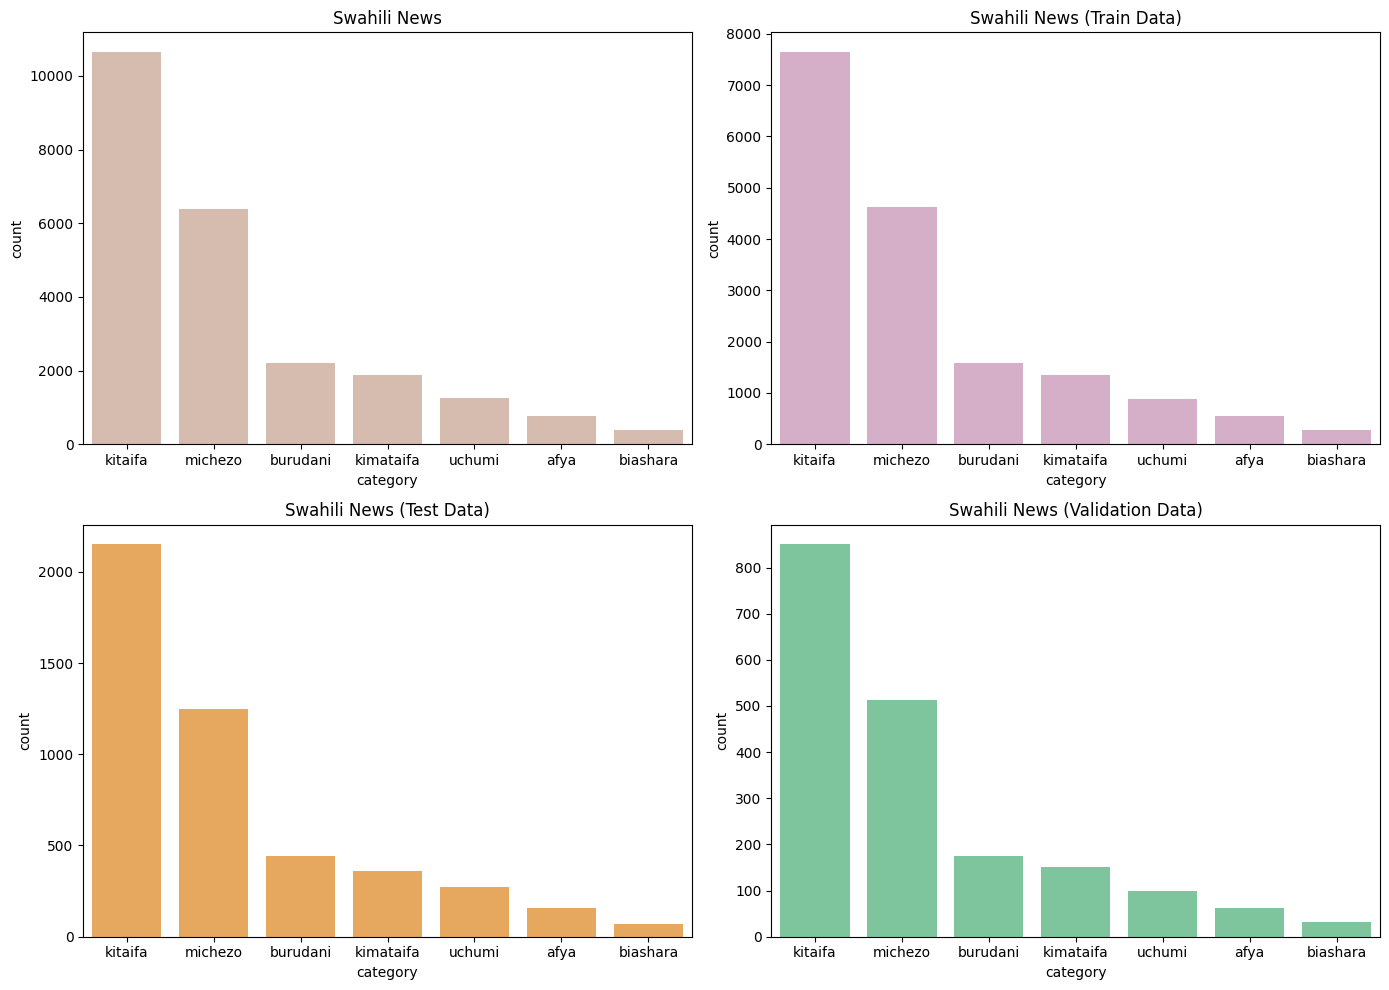

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(
    x="category",
    data=merged_swahili_news,
    color="#dbbaa9",
    order=merged_swahili_news["category"].value_counts().index,
    ax=ax[0,0]
    ).set_title("Swahili News")

sns.countplot(
    x="category",
    data=train_merged_swahili_news,
    color="#dba9ca",
    order=train_merged_swahili_news["category"].value_counts().index,
    ax=ax[0,1]
    ).set_title("Swahili News (Train Data)")

sns.countplot(
    x="category",
    data=test_merged_swahili_news,
    color="#fdaa48",
    order=test_merged_swahili_news["category"].value_counts().index,
    ax=ax[1,0]
    ).set_title("Swahili News (Test Data)")

sns.countplot(
    x="category",
    data=validation_merged_swahili_news,
    color="#72d09c",
    order=validation_merged_swahili_news["category"].value_counts().index,
    ax=ax[1,1]
    ).set_title("Swahili News (Validation Data)")

plt.tight_layout()

In [ ]:
# def collate(batch):
#     samples, labels = zip(*batch)
#     samples_padded = nn.utils.rnn.pad_sequence(samples, batch_first=True, padding_value=0)
#     return samples_padded, torch.tensor(labels)

# def inference_collate(batch):
#     # samples = zip(*batch)
#     samples_padded = nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0)
#     return samples_padded

# class SamplesDataset(Dataset):
#     def __init__(self, data):
#         self.samples = data["token_ids"].values
#         self.targets = data["target"].values

#     def __getitem__(self, index):
#         sample = self.samples[index]
#         target = self.targets[index]
#         # return target
#         return torch.tensor(sample, dtype=torch.long), torch.tensor(target, dtype=torch.long)

#     def __len__(self):
#         return len(self.samples)

# class InferenceSamplesDataset(Dataset):
#     def __init__(self, data):
#         self.samples = data["token_ids"].values

#     def __getitem__(self, index):
#         sample = self.samples[index]
#         return torch.tensor(sample, dtype=torch.long)

#     def __len__(self):
#         return len(self.samples)

# train_data = SamplesDataset(train_merged_swahili_news)
# validation_data = SamplesDataset(validation_merged_swahili_news)

# train_loader = DataLoader(train_data, collate_fn=collate, shuffle=True, batch_size=64)
# validation_loader = DataLoader(validation_data, collate_fn=collate, shuffle=True, batch_size=64)

In [ ]:
merged_swahili_news["target"].nunique()

7

In [ ]:
# # Implementing LSTM

# class SamplesLSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, dimension):
#         super().__init__()
#         self.dimension = dimension
#         self.vocab_size = vocab_size
#         self.lstm = nn.LSTM(
#             self.dimension,
#             self.dimension,
#             num_layers=2,
#             # dropout=0.3,
#             batch_first=True,
#             bidirectional=True,
#             )
#         self.dropout = nn.Dropout(0.3)
#         self.embedding = nn.Embedding(self.vocab_size, self.dimension, padding_idx=0)
#         self.classification = nn.Linear(self.dimension * 2, 7)

#     def forward(self,ins):
#         # ins = ins.squeeze(1)
#         embeddings = self.embedding(ins)
#         # print(f"Before LSTM: {embeddings.shape}")
#         output, (h_n, c_n) = self.lstm(embeddings)

#         h = torch.cat((h_n[-2], h_n[-1]), dim=1)
#         h = self.dropout(h)

#         return self.classification(h)
#         # return self.classification(h_n[-1])

In [ ]:
# max(max(chunk) for doc in merged_swahili_news["token_ids"] for chunk in doc) >= tokenizer.vocab_size

In [ ]:
merged_swahili_news.columns

Index(['id', 'content', 'category', 'target'], dtype='object')

In [ ]:
# merged_swahili_news["tokenized"].head(1)

In [ ]:
# vocab = {word for phrase in merged_swahili_news["tokenized"] for word in phrase}

In [ ]:
# for sample, target in train_loader:
#     print(target)
#     # print(target.squeeze(1))
#     print(f"Sample shape: {sample.shape}")
#     print(f"Target shape: {target.shape}")
#     print(target.ndim)
#     break

In [ ]:
# merged_swahili_news[merged_swahili_news["target"] == 4][["category", "target"]].head()

In [ ]:
# len(train_loader)

In [ ]:
len(merged_swahili_news)

23508

In [ ]:
# for batch_X, batch_y in train_loader:
#     print(batch_X.shape)
#     print(batch_y.shape)
#     break

In [ ]:
# dimension = 512
# epochs = 10
# vocab_size = tokenizer.vocab_size

# lossFct = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss()


# lstm_model = SamplesLSTMClassifier(vocab_size, dimension)
# optimizer = torch.optim.AdamW(lstm_model.parameters())

# losses = []
# val_losses = []

# best_val_loss = float("inf")
# patience = 3
# counter = 0
# for epoch in range(epochs):
#     lossAbs = 0
#     epoch_loss = 0
#     num_batch = 0
#     # counter = 0
#     progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

#     for sample, target in progress_bar:
#         # print(f"Sample count: {counter}")
#         outputs = lstm_model(sample)
#         loss = lossFct(outputs, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#         num_batch += 1
#         # counter+=1
#         progress_bar.set_postfix(loss=f"{epoch_loss/num_batch:.4f}")

#     losses.append(epoch_loss/num_batch)

#     lstm_model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_targets = []

#     with torch.no_grad():
#         for sample, target in validation_loader:
#             outputs = lstm_model(sample)
#             loss = criterion(outputs, target)
#             val_loss += loss.item()

#             preds = outputs.argmax(dim=1)
#             correct += (preds == target).sum().item()
#             total += target.size(0)

#             all_predictions.append(preds)
#             all_targets.append(target)

#     val_loss /= len(validation_loader)
#     val_acc = correct / total
#     val_losses.append(val_loss)

#     print(f"Epoch[{epoch+1}/{epochs}], Train Loss: {epoch_loss/num_batch:.4f}, Val Loss: {val_loss:.4f}")


#     # if val_loss < best_val_loss:
#     #     best_val_loss = val_loss
#     #     counter = 0
#     # else:
#     #     counter += 1

#     # if counter >= patience:
#     #     print(f"Early stopping at epoch {epoch+1} and saving the model")
#     #     torch.save({
#     #         "model_state_dict": lstm_model.state_dict(),
#     #         "vocab_size": vocab_size,
#     #         "dimension": dimension}, "best_model.pt")
#     #     break

#     # print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/num_batch}")

In [ ]:
# # plotting the training
# fig, ax = plt.subplots(1, 2, figsize=(8, 5))
# ax[0].plot(losses, color="#dba9b1")
# ax[0].set(title="Training Loss (LSTM)", xlabel="Epoch", ylabel="Loss")
# ax[1].plot(val_losses, color="#a9b1db")
# ax[1].set(title="Validation Loss (LSTM)", xlabel="Epoch", ylabel="Loss")

# plt.tight_layout()
# plt.show()

In [ ]:
#    # Concatenate all batches
# all_predictions = torch.cat(all_predictions)
# all_targets = torch.cat(all_targets)
# num_classes = 7

# precision_list = []
# recall_list = []
# f1_list = []

# for cls in range(num_classes):
#     tp = ((all_predictions == cls) & (all_targets == cls)).sum().item()
#     fp = ((all_predictions == cls) & (all_targets != cls)).sum().item()
#     fn = ((all_predictions != cls) & (all_targets == cls)).sum().item()
#     precision = tp / (tp + fp) if tp + fp > 0 else 0
#     recall = tp / (tp + fn) if tp + fn > 0 else 0
#     f1 = (
#         2 * precision * recall / (precision + recall)
#         if precision + recall > 0
#         else 0
#     )
#     precision_list.append(precision)
#     recall_list.append(recall)
#     f1_list.append(f1)

#     accuracy = correct / total
#     macro_precision = sum(precision_list) / num_classes
#     macro_recall = sum(recall_list) / num_classes
#     macro_f1 = sum(f1_list) / num_classes


In [ ]:
# print(f"Baseline LSTM\n----------\nAccuracy: {accuracy:.4f}\nF1 Score: {macro_f1:.4f}")

In [ ]:
# # Implementing self attention layer on LSTM

# class SamplesAttentionLSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, dimension):
#         super().__init__()
#         self.dimension = dimension
#         self.vocab_size = vocab_size
#         self.lstm = nn.LSTM(
#             self.dimension,
#             self.dimension,
#             num_layers=2,
#             # dropout=0.3,
#             batch_first=True,
#             bidirectional=True,
#             )
#         self.attention = nn.Linear(self.dimension * 2, 1)
#         self.dropout = nn.Dropout(0.3)
#         self.embedding = nn.Embedding(self.vocab_size, self.dimension, padding_idx=0)
#         self.classification = nn.Linear(self.dimension * 2, 7)

#     def forward(self,ins):
#         # ins = ins.squeeze(1)
#         embeddings = self.embedding(ins)
#         # print(f"Before LSTM: {embeddings.shape}")
#         output, (h_n, c_n) = self.lstm(embeddings)

#         # attention scores
#         attn_scores = self.attention(output)

#         # [batch, seq_len]
#         attn_scores = attn_scores.squeeze(-1)

#         # normalize
#         attn_weights = nn.functional.softmax(attn_scores, dim=1)

#         # [batch, seq_len, 1]
#         attn_weights = attn_weights.unsqueeze(-1)

#         # weighted sum
#         context = torch.sum(attn_weights * output, dim=1)

#         # h = torch.cat((h_n[-2], h_n[-1]), dim=1)
#         context = self.dropout(context)

#         return self.classification(context)
#         # return self.classification(h_n[-1])

In [ ]:
# dimension = 512
# epochs = 10
# vocab_size = tokenizer.vocab_size

# lossFct = nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss()


# lstm_model = SamplesAttentionLSTMClassifier(vocab_size, dimension)
# optimizer = torch.optim.AdamW(lstm_model.parameters())

# losses = []
# val_losses = []

# best_val_loss = float("inf")
# patience = 3
# counter = 0
# for epoch in range(epochs):
#     lossAbs = 0
#     epoch_loss = 0
#     num_batch = 0
#     # counter = 0
#     progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

#     for sample, target in progress_bar:
#         # print(f"Sample count: {counter}")
#         outputs = lstm_model(sample)
#         loss = lossFct(outputs, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#         num_batch += 1
#         # counter+=1
#         progress_bar.set_postfix(loss=f"{epoch_loss/num_batch:.4f}")

#     losses.append(epoch_loss/num_batch)

#     lstm_model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0
#     all_predictions = []
#     all_targets = []

#     with torch.no_grad():
#         for sample, target in validation_loader:
#             outputs = lstm_model(sample)
#             loss = criterion(outputs, target)
#             val_loss += loss.item()

#             preds = outputs.argmax(dim=1)
#             correct += (preds == target).sum().item()
#             total += target.size(0)

#             all_predictions.append(preds)
#             all_targets.append(target)

#     val_loss /= len(validation_loader)
#     val_acc = correct / total
#     val_losses.append(val_loss)

#     print(f"Epoch[{epoch+1}/{epochs}], Train Loss: {epoch_loss/num_batch:.4f}, Val Loss: {val_loss:.4f}")


#     # if val_loss < best_val_loss:
#     #     best_val_loss = val_loss
#     #     counter = 0
#     # else:
#     #     counter += 1

#     # if counter >= patience:
#     #     print(f"Early stopping at epoch {epoch+1} and saving the model")
#     #     torch.save({
#     #         "model_state_dict": lstm_model.state_dict(),
#     #         "vocab_size": vocab_size,
#     #         "dimension": dimension}, "best_model.pt")
#     #     break

#     # print(f"Epoch[{epoch+1}/{epochs}], Loss: {epoch_loss/num_batch}")

In [ ]:
# # Concatenate all batches
# all_predictions = torch.cat(all_predictions)
# all_targets = torch.cat(all_targets)
# num_classes = 7

# precision_list = []
# recall_list = []
# f1_list = []

# for cls in range(num_classes):
#     tp = ((all_predictions == cls) & (all_targets == cls)).sum().item()
#     fp = ((all_predictions == cls) & (all_targets != cls)).sum().item()
#     fn = ((all_predictions != cls) & (all_targets == cls)).sum().item()
#     precision = tp / (tp + fp) if tp + fp > 0 else 0
#     recall = tp / (tp + fn) if tp + fn > 0 else 0
#     f1 = (
#         2 * precision * recall / (precision + recall)
#         if precision + recall > 0
#         else 0
#     )
#     precision_list.append(precision)
#     recall_list.append(recall)
#     f1_list.append(f1)

#     accuracy = correct / total
#     macro_precision = sum(precision_list) / num_classes
#     macro_recall = sum(recall_list) / num_classes
#     macro_f1 = sum(f1_list) / num_classes


In [ ]:
# print(f"Attention w LSTM\n----------\nAccuracy: {accuracy:.4f}\nF1 Score: {macro_f1:.4f}")

In [ ]:
# # plotting the training
# fig, ax = plt.subplots(1, 2, figsize=(8, 5))
# ax[0].plot(losses, color="#dba9b1")
# ax[0].set(title="Training Loss (LSTM)", xlabel="Epoch", ylabel="Loss")
# ax[1].plot(val_losses, color="#a9b1db")
# ax[1].set(title="Validation Loss (LSTM)", xlabel="Epoch", ylabel="Loss")

# plt.tight_layout()
# plt.show()

In [ ]:
import psutil, torch
print(f"RAM available: {psutil.virtual_memory().available / 1e9:.1f} GB")
if torch.cuda.is_available():
    print(f"GPU VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

RAM available: 11.5 GB


In [ ]:
# # model_checkpoint = "castorini/afriteva_base"
# # model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
device = torch.device("cpu")
model = AutoModelForSequenceClassification.from_pretrained("castorini/afriberta_small", num_labels=7, low_cpu_mem_usage=True)
afriberta_tokenizer = AutoTokenizer.from_pretrained("castorini/afriberta_small")

afriberta_tokenizer.model_max_length = 512

model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_small
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=7, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(70006, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-3): 4 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linea

In [ ]:
class AfribertaDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=64):
        self.texts = data["content"].reset_index(drop=True)
        self.labels = data["target"].reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = AfribertaDataset(train_merged_swahili_news, afriberta_tokenizer)
validation_dataset = AfribertaDataset(validation_merged_swahili_news, afriberta_tokenizer)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=64)
validation_loader = DataLoader(validation_dataset, shuffle=True, batch_size=64)

In [ ]:
for batch in train_loader:
  print(batch)
  break

{'input_ids': tensor([[    0,   266, 12768,  ...,  8153,   703,     2],
        [    0,  1974,   272,  ..., 14725, 19771,     2],
        [    0,  1810, 49583,  ...,  1368,   266,     2],
        ...,
        [    0,   261, 11064,  ..., 24742,   268,     2],
        [    0,  2060,   268,  ...,  2366,   272,     2],
        [    0, 60377,   774,  ...,  1197,  4334,     2]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([4, 4, 4, 2, 5, 4, 5, 6, 4, 1, 6, 2, 3, 5, 4, 4, 2, 0, 0, 4, 4, 4, 5, 5,
        3, 3, 2, 4, 4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 5, 5, 4, 4, 2, 5, 5, 4, 4,
        0, 4, 3, 5, 5, 4, 5, 3, 4, 4, 4, 2, 4, 2, 4, 1])}


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
epochs = 5
losses = []

from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

epochs = 5

train_losses = []
val_losses = []
val_accuracies = []
val_f1_scores = []

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    epoch_train_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{epochs}]",
        leave=False
    )

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / (progress_bar.n + 1)

        progress_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}"
        )

    avg_epoch_train_loss = epoch_train_loss / len(train_loader)

    train_losses.append(avg_epoch_train_loss)

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    epoch_val_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for batch in validation_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            epoch_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    avg_epoch_val_loss = epoch_val_loss / len(validation_loader)
    val_accuracy = correct / total
    val_f1 = f1_score(
        all_targets,
        all_predictions,
        average="weighted"
    )

    val_losses.append(avg_epoch_val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    # =========================
    # EPOCH RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_epoch_train_loss:.4f} | "
        f"Val Loss: {avg_epoch_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

# =========================
# FINAL CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")

print(
    classification_report(
        all_targets,
        all_predictions
    )
)

Epoch [1/5] | Train Loss: 0.5532 | Val Loss: 0.3645 | Val Acc: 0.8857 | Val F1: 0.8756


Epoch [2/5] | Train Loss: 0.3332 | Val Loss: 0.3305 | Val Acc: 0.8953 | Val F1: 0.8863


Epoch [3/5] | Train Loss: 0.2748 | Val Loss: 0.3371 | Val Acc: 0.8969 | Val F1: 0.8881


Epoch [4/5] | Train Loss: 0.2275 | Val Loss: 0.3600 | Val Acc: 0.8958 | Val F1: 0.8864


Epoch [5/5] | Train Loss: 0.1903 | Val Loss: 0.3882 | Val Acc: 0.8931 | Val F1: 0.8854

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.42      0.56        62
           1       0.50      0.03      0.06        31
           2       0.90      0.89      0.89       175
           3       0.93      0.83      0.87       151
           4       0.90      0.93      0.92       850
           5       0.95      0.97      0.96       514
           6       0.60      0.83      0.70        98

    accuracy                           0.89      1881
   macro avg       0.80      0.70      0.71      1881
weighted avg       0.89      0.89      0.89      1881



In [ ]:
metrics_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_acc": val_accuracies,
    "val_f1": val_f1_scores
})

metrics_df.to_csv(
    "/content/drive/MyDrive/afriberta_metrics.csv",
    index=False
)

In [ ]:
# # tokenize the dataset

# def afriberta_tokenize(text):
#     encoding = afriberta_tokenizer(
#                     text,
#                     max_length=512,
#                     truncation=True,
#                     stride=128,
#                     return_overflowing_tokens=True,
#                     padding="max_length"
#                     )
#     tokens = [afriberta_tokenizer.convert_ids_to_tokens(ids) for ids in encoding["input_ids"]][0]
#     token_ids = encoding["input_ids"]
#     return tokens, token_ids

# merged_swahili_news["afriberta_tokenized"] = merged_swahili_news["content"].apply(lambda x: afriberta_tokenize(x)[0])

# merged_swahili_news.head(2)

In [ ]:
for batch, _ in train_loader:
    print(batch)
    print(batch[0])
    print(batch.ndim)
    break

ValueError: too many values to unpack (expected 2)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
epochs = 15
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for input_ids, labels in progress_bar:
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{epoch_loss/len(train_loader):.4f}")

    losses.append(epoch_loss / len(train_loader))
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {losses[-1]:.4f}")

In [ ]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# model.to(device)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [ ]:
# dataset.set_format(
#     type="torch",
#     columns=["input_ids", "attention_mask", "label"]
# )

In [ ]:
model.train()

for epoch in range(3):

    total_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=inputs,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

In [ ]:
batch = next(iter(train_loader))
print(type(batch))

In [ ]:
batch = next(iter(train_loader))

print(type(batch))

if isinstance(batch, dict):
    print(batch.keys())

    for key, value in batch.items():
        print(key, value.shape)

else:
    print(batch)